# 3D Grounding-DETR Visualization Demo

This notebook demonstrates how to visualize predictions from the 3D Grounding-DETR model on CT volumes.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import random_split

from models import build_model
from datasets import RSNAVolumeDataset
from utils.visualization import (
    visualize_single_slice,
    visualize_multi_slice,
    save_visualization
)
from utils.metrics import compute_map

%matplotlib inline

## 1. Load Model and Dataset

In [2]:
# Configuration
CHECKPOINT_PATH = 'checkpoints/model_best.pth'
DATA_DIR = '/home/woody/iwi5/iwi5378h/rsna2023'
SAMPLE_IDX = 0  # Index within test dataset
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# Load checkpoint
print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
config = checkpoint['config']

# Build model
print("Building model...")
model = build_model(config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

Loading checkpoint from checkpoints/model_best.pth...
Building model...


/home/hpc/iwi5/iwi5378h/miniconda3/envs/3d-detection/lib/python3.8/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Model built with 42,451,134 parameters
Model loaded successfully!


In [4]:
# Load full dataset and split into train/val/test using the same logic as train.py
print(f"Loading dataset from {DATA_DIR}...")

# Create full dataset (without augmentation for evaluation)
full_dataset = RSNAVolumeDataset(
    data_dir=DATA_DIR,
    target_width=config['data']['target_width'],
    train=False,
    augment=False,
    image_format=config['data'].get('image_format', 'dcm')
)

# Use the same split ratios and seed as training
train_ratio = config['data'].get('train_split', 0.7)
val_ratio = config['data'].get('val_split', 0.15)
test_ratio = config['data'].get('test_split', 0.15)
random_seed = config['data'].get('random_seed', 42)

# Normalize ratios
total_ratio = train_ratio + val_ratio + test_ratio
train_ratio /= total_ratio
val_ratio /= total_ratio
test_ratio /= total_ratio

# Calculate split sizes
total_size = len(full_dataset)
train_size = int(total_size * train_ratio)
val_size = int(total_size * val_ratio)
test_size = total_size - train_size - val_size

# Split with the SAME seed as training for reproducibility
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(random_seed)
)

print(f"Full dataset size: {len(full_dataset)}")
print(f"Split: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

# Print file IDs for each split (remove after verification)
def _get_ids(subset): return [full_dataset.seg_files[i].replace('.nii','') for i in subset.indices]
print(f"Train IDs: {_get_ids(train_dataset)}")
print(f"Val IDs: {_get_ids(val_dataset)}")
print(f"Test IDs: {_get_ids(test_dataset)}")

Loading dataset from /home/woody/iwi5/iwi5378h/rsna2023...
Excluding 12102: no corresponding image data found
Excluding 12402: no corresponding image data found
Excluding 13848: no corresponding image data found
Excluding 17225: no corresponding image data found
Excluding 24149: no corresponding image data found
Excluding 25349: no corresponding image data found
Excluding 34232: no corresponding image data found
Excluding 40781: no corresponding image data found
Excluding 41663: no corresponding image data found
Excluding 50212: no corresponding image data found
Excluding 55928: no corresponding image data found
Excluding 7384: no corresponding image data found
Excluding 778: no corresponding image data found
Found 193 segmentation files with corresponding images
Image format: dcm
Full dataset size: 193
Split: train=135, val=28, test=30
Train IDs: ['16066', '47155', '17605', '10252', '4622', '31021', '6305', '7818', '40471', '1201', '22232', '6130', '21057', '26343', '12674', '18207', 

## 2. Run Inference

In [5]:
# Get sample from TEST dataset
sample = test_dataset[SAMPLE_IDX]
volume = sample['volume']  # (1, D, H, W)
series_id = sample['study_id']
gt_boxes = sample['boxes'].numpy()
gt_labels = sample['labels'].numpy()

print(f"[TEST Sample {SAMPLE_IDX}]")
print(f"Series ID: {series_id}")
print(f"Volume shape: {volume.shape}")
print(f"Ground truth objects: {len(gt_boxes)}")

[TEST Sample 0]
Series ID: 45406
Volume shape: torch.Size([1, 28, 128, 128])
Ground truth objects: 5


In [6]:
# Run inference
print("Running inference...")
with torch.no_grad():
    volume_input = volume.unsqueeze(0).to(DEVICE).float()  # (1, 1, D, H, W)
    outputs = model(volume_input)
    
    pred_logits = outputs['pred_logits'][0]  # (num_queries, num_classes+1)
    pred_boxes = outputs['pred_boxes'][0]    # (num_queries, 6)
    
    # Get scores and labels
    pred_scores = pred_logits.softmax(-1)
    pred_labels = pred_scores[:, :-1].argmax(-1)  # Exclude background
    pred_scores = pred_scores.max(-1)[0]
    
    # Move to CPU
    pred_boxes = pred_boxes.cpu().numpy()
    pred_labels = pred_labels.cpu().numpy()
    pred_scores = pred_scores.cpu().numpy()

print("Inference complete!")

Running inference...
Inference complete!


In [7]:
# Post-processing: Get the top prediction for each class
# Select the highest-scoring prediction per class

num_classes = config['model']['num_classes']

# Get per-class scores (exclude background which is the last class)
class_scores = pred_logits.softmax(-1)[:, :-1]  # (num_queries, num_classes)

# For each class, find the query with the highest score
pred_boxes_per_class = []
pred_labels_per_class = []
pred_scores_per_class = []

for class_id in range(num_classes):
    # Get scores for this class
    scores_for_class = class_scores[:, class_id]
    
    # Find the query with the highest score for this class
    best_query_idx = scores_for_class.argmax().item()
    best_score = scores_for_class[best_query_idx].item()
    
    # Only include if score is above a minimum threshold (to filter out very low confidence)
    MIN_SCORE = 0.0  # Minimum confidence threshold
    if best_score >= MIN_SCORE:
        pred_boxes_per_class.append(pred_boxes[best_query_idx])
        pred_labels_per_class.append(class_id)
        pred_scores_per_class.append(best_score)

# Convert to arrays
if len(pred_boxes_per_class) > 0:
    pred_boxes_filtered = np.array(pred_boxes_per_class)
    pred_labels_filtered = np.array(pred_labels_per_class)
    pred_scores_filtered = np.array(pred_scores_per_class)
else:
    pred_boxes_filtered = np.zeros((0, 6))
    pred_labels_filtered = np.zeros((0,), dtype=np.int64)
    pred_scores_filtered = np.zeros((0,))

print(f"Predictions (top-1 per class, score >= {MIN_SCORE}): {len(pred_boxes_filtered)}")
for i, (box, label, score) in enumerate(zip(pred_boxes_filtered, pred_labels_filtered, pred_scores_filtered)):
    print(f"  {i+1}. Class {label}, Score: {score:.3f}")

Predictions (top-1 per class, score >= 0.0): 5
  1. Class 0, Score: 0.998
  2. Class 1, Score: 0.998
  3. Class 2, Score: 0.999
  4. Class 3, Score: 1.000
  5. Class 4, Score: 0.993


## 3. Single-Slice Visualization

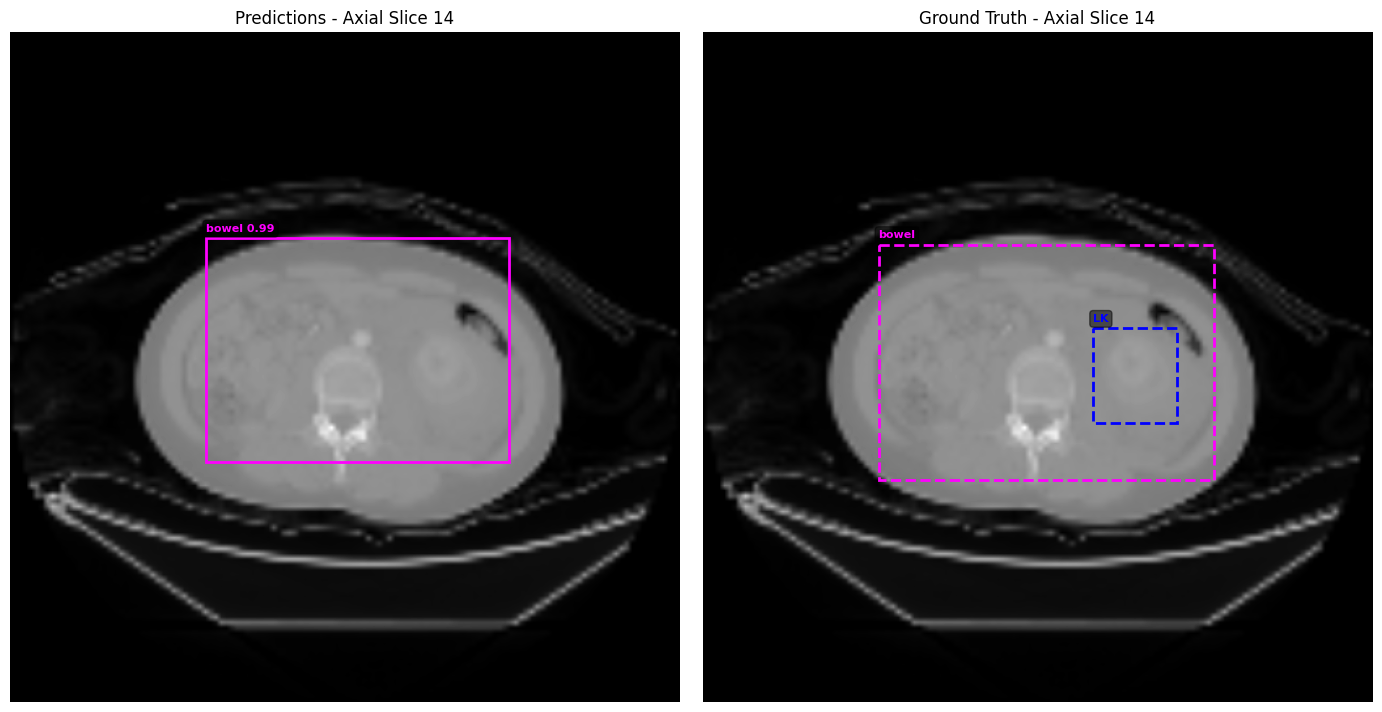

In [8]:
# Visualize middle slice
volume_np = volume[0].numpy()  # Remove channel dimension
middle_slice = volume_np.shape[0] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=middle_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='axial',
    figsize=(14, 7)
)

plt.show()

## 4. Multi-Slice Visualization (Axial & Sagittal & Coronal)

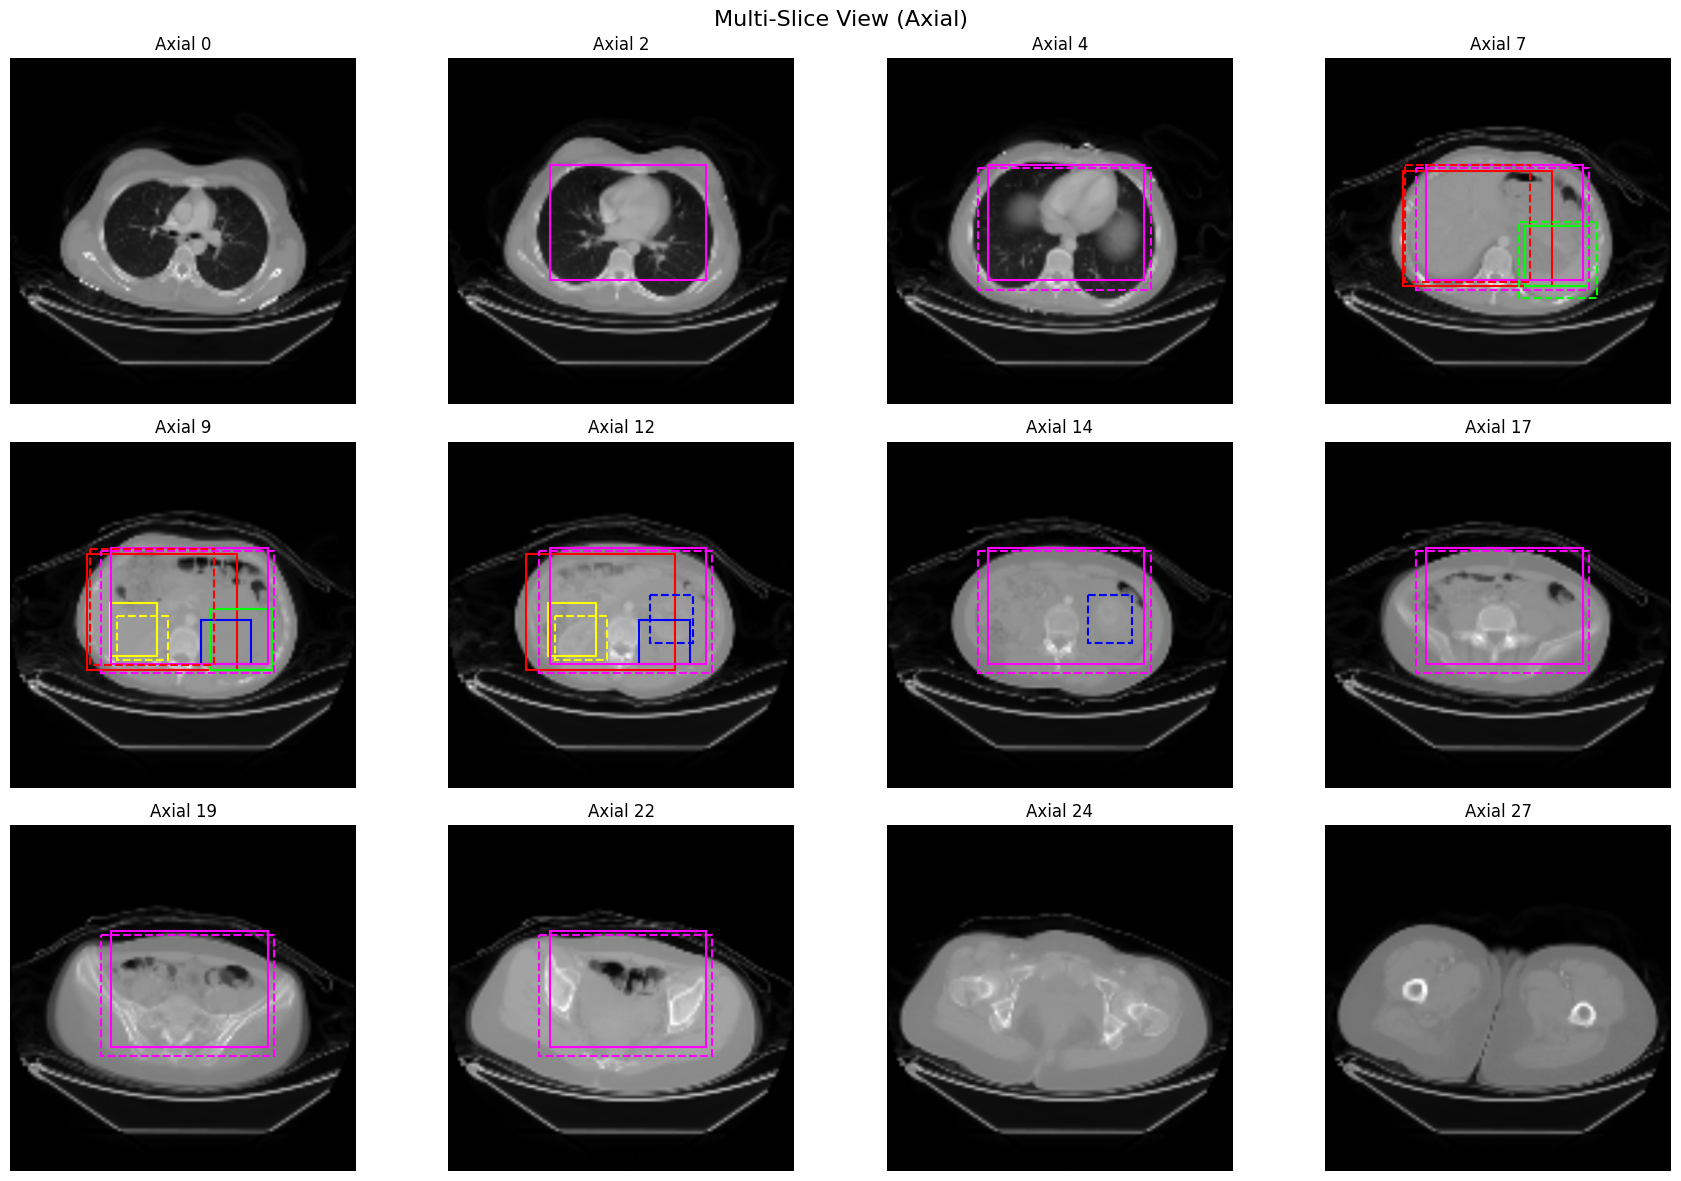

In [9]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='axial',
    figsize=(18, 12)
)

plt.show()

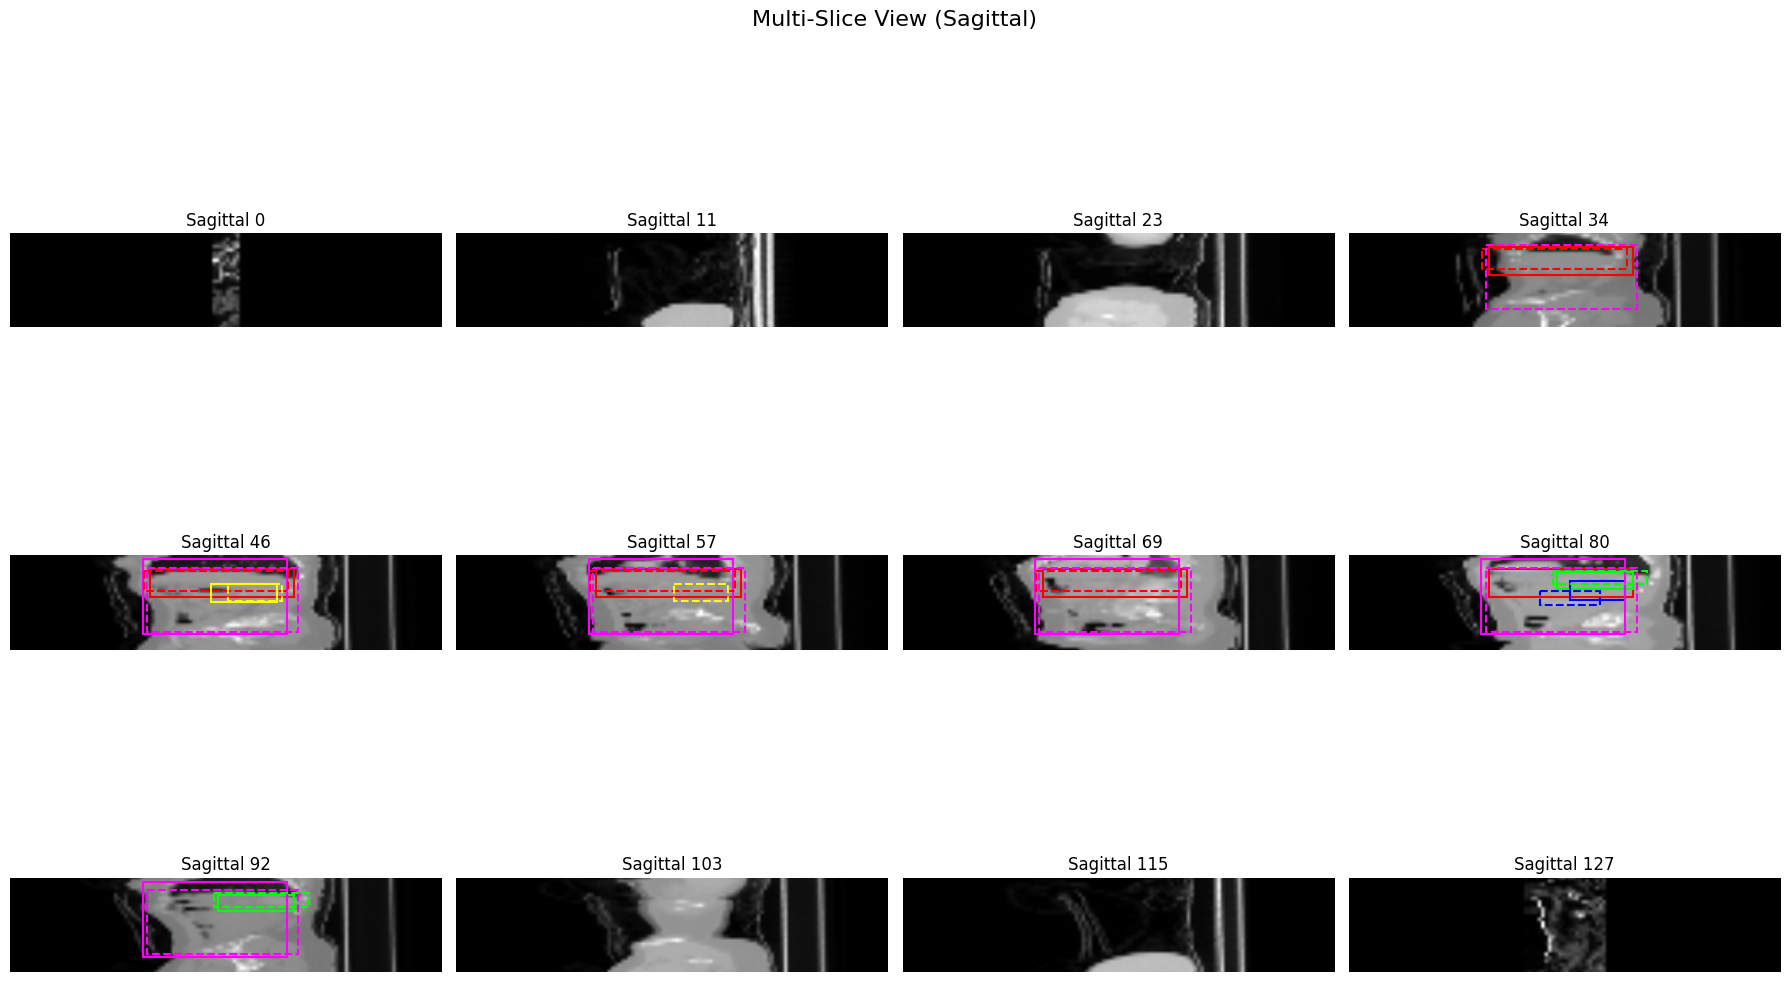

In [10]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='sagittal',
    figsize=(18, 12)
)

plt.show()

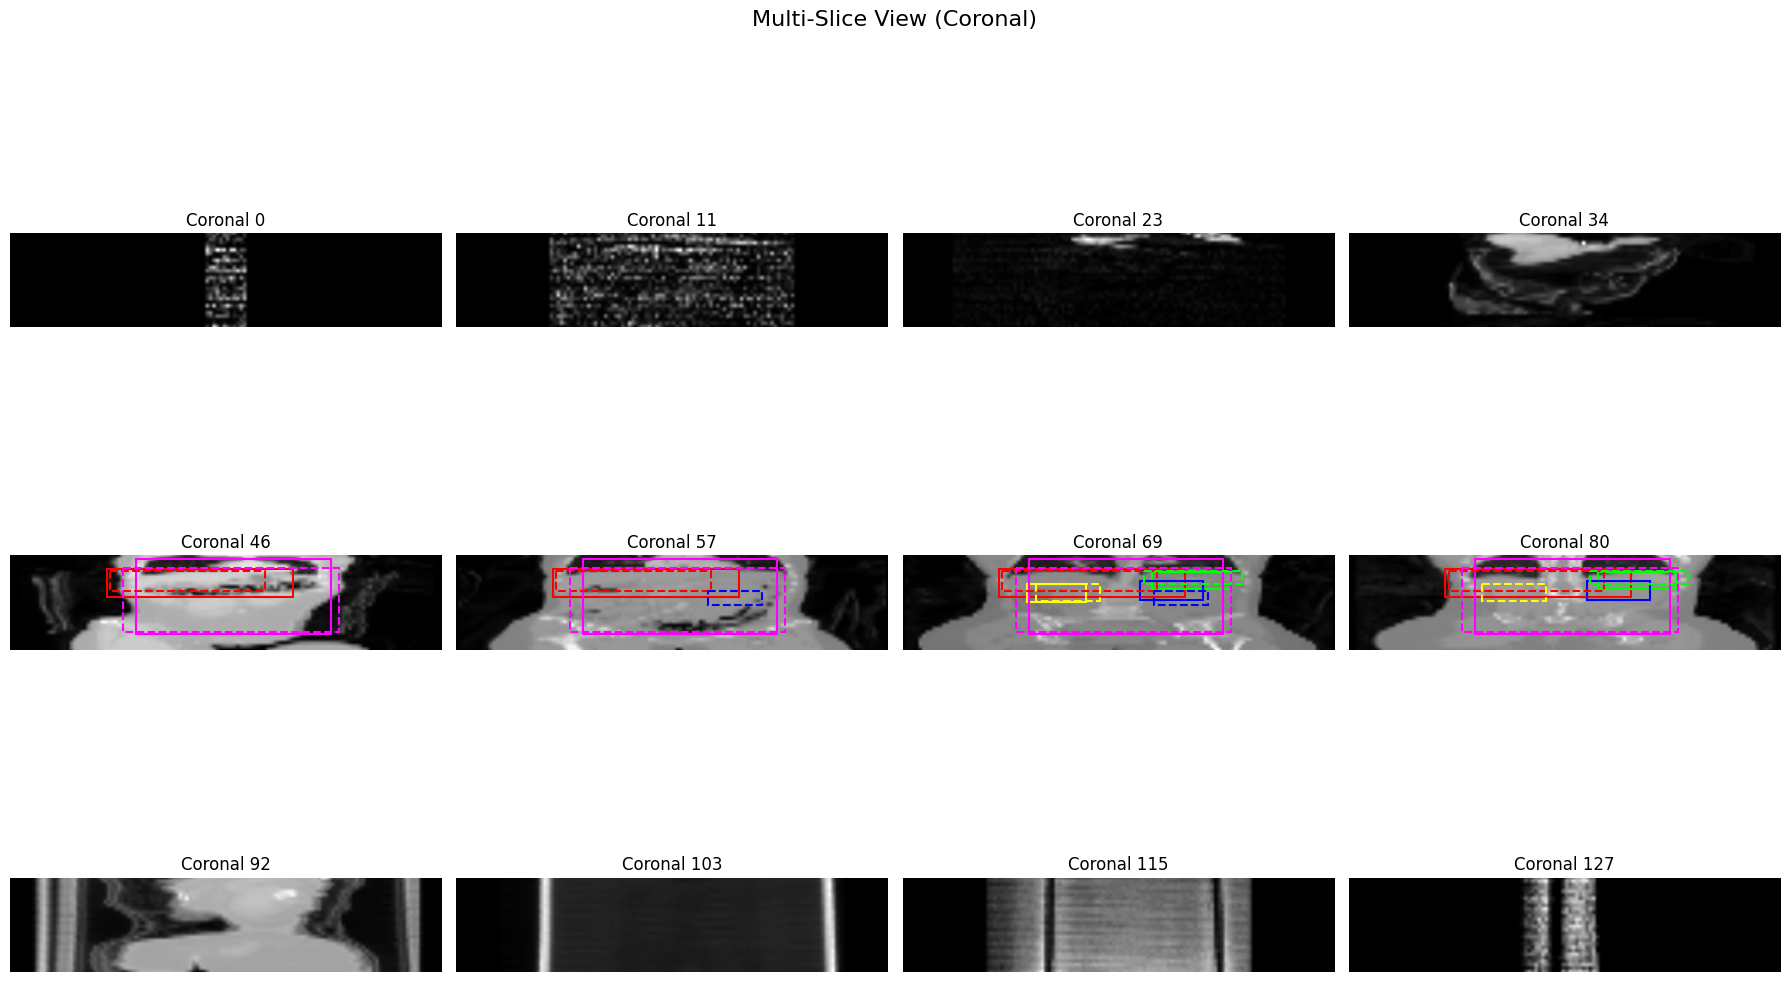

In [11]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='coronal',
    figsize=(18, 12)
)

plt.show()

## 5. Calculate mAP (Mean Average Precision)

In [12]:
# Prepare predictions and ground truths in the format required by compute_map
# The function expects a list of dictionaries

predictions = [{
    'boxes': pred_boxes,  # All predictions (not filtered)
    'scores': pred_scores,
    'labels': pred_labels
}]

ground_truths = [{
    'boxes': gt_boxes,
    'labels': gt_labels
}]

# Number of classes in your dataset
num_classes = config['model']['num_classes']

print(f"Number of classes: {num_classes}")
print(f"Predictions: {len(pred_boxes)} boxes")
print(f"Ground truths: {len(gt_boxes)} boxes")

Number of classes: 5
Predictions: 10 boxes
Ground truths: 5 boxes


In [13]:
# Compute mAP at different IoU thresholds
iou_thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

map_results = compute_map(
    predictions=predictions,
    ground_truths=ground_truths,
    num_classes=num_classes,
    iou_thresholds=iou_thresholds
)

print("\n" + "="*50)
print("mAP Results:")
print("="*50)
for metric_name, value in map_results.items():
    print(f"{metric_name}: {value:.4f}")
print("="*50)


mAP Results:
mAP@0.1: 0.0000
mAP@0.3: 0.0000
mAP@0.5: 0.0000
mAP@0.7: 0.0000
mAP@0.9: 0.0000
mAP: 0.0000


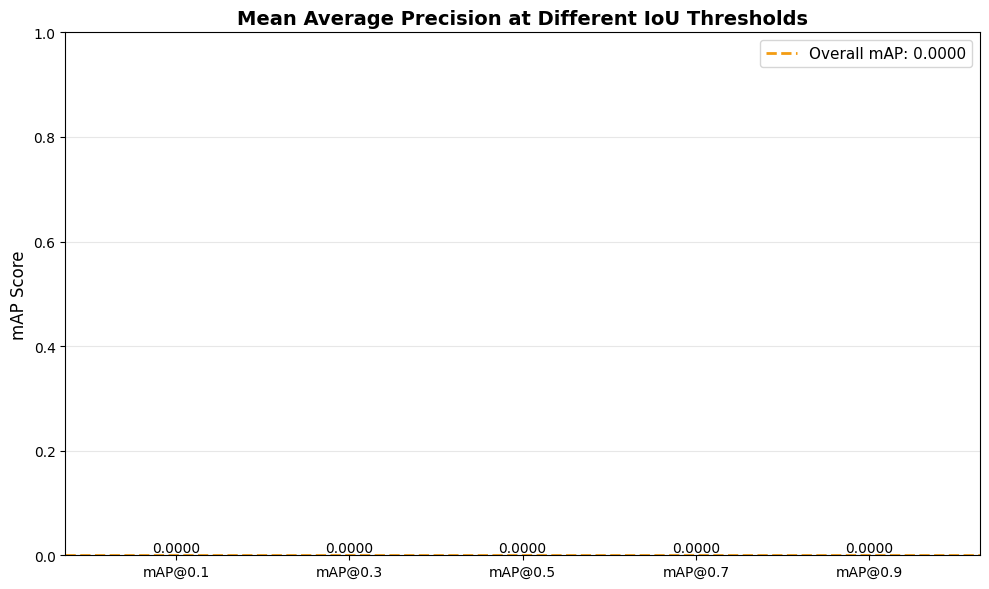

In [14]:
# Visualize mAP results
import matplotlib.pyplot as plt

# Create a bar plot
metrics = [k for k in map_results.keys() if k != 'mAP']
values = [map_results[k] for k in metrics]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.axhline(y=map_results['mAP'], color='#f39c12', linestyle='--', 
           linewidth=2, label=f"Overall mAP: {map_results['mAP']:.4f}")

ax.set_ylabel('mAP Score', fontsize=12)
ax.set_title('Mean Average Precision at Different IoU Thresholds', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Evaluate mAP on the ENTIRE TEST dataset
NUM_TEST_SAMPLES = len(test_dataset)

all_predictions = []
all_ground_truths = []

print(f"Evaluating on entire TEST dataset ({NUM_TEST_SAMPLES} samples)...")
print("=" * 50)

from tqdm import tqdm

for idx in tqdm(range(NUM_TEST_SAMPLES), desc="Running inference on test set"):
    sample = test_dataset[idx]
    volume = sample['volume']
    
    # Run inference
    with torch.no_grad():
        volume_input = volume.unsqueeze(0).to(DEVICE).float()
        outputs = model(volume_input)
        
        pred_logits = outputs['pred_logits'][0]
        pred_boxes = outputs['pred_boxes'][0]
        
        pred_scores = pred_logits.softmax(-1)
        pred_labels = pred_scores[:, :-1].argmax(-1)
        pred_scores = pred_scores.max(-1)[0]
        
        # Store predictions
        all_predictions.append({
            'boxes': pred_boxes.cpu().numpy(),
            'scores': pred_scores.cpu().numpy(),
            'labels': pred_labels.cpu().numpy()
        })
        
    # Store ground truths
    all_ground_truths.append({
        'boxes': sample['boxes'].numpy(),
        'labels': sample['labels'].numpy()
    })

# Compute mAP on entire test set
test_map_results = compute_map(
    predictions=all_predictions,
    ground_truths=all_ground_truths,
    num_classes=num_classes,
    iou_thresholds=iou_thresholds
)

print("\n" + "=" * 60)
print(f"📊 FINAL TEST SET RESULTS ({NUM_TEST_SAMPLES} samples)")
print("=" * 60)
print("⚠️  These samples were NEVER seen during training or validation!")
print("-" * 60)
for metric_name, value in test_map_results.items():
    print(f"{metric_name}: {value:.4f}")
print("=" * 60)

Evaluating on entire TEST dataset (30 samples)...


Running inference on test set: 100%|██████████| 30/30 [11:09<00:00, 22.33s/it]



📊 FINAL TEST SET RESULTS (30 samples)
⚠️  These samples were NEVER seen during training or validation!
------------------------------------------------------------
mAP@0.1: 0.8367
mAP@0.3: 0.6275
mAP@0.5: 0.2747
mAP@0.7: 0.0575
mAP@0.9: 0.0000
mAP: 0.3593
